In [2]:
import os
import json
import shutil
import random
from pathlib import Path

# =========================================================
# 1. 원본 경로
# =========================================================
label_root = Path(r"C:\py_temp\new_proj\위험지역_사람포착\136.야간 사건사고 대응을 위한 버드아이뷰 IR열화상 데이터\01.데이터\1.Training\라벨링데이터")
image_root = Path(r"C:\py_temp\new_proj\위험지역_사람포착\136.야간 사건사고 대응을 위한 버드아이뷰 IR열화상 데이터\01.데이터\1.Training\원천데이터\TS_객체데이터이미지\객체데이터이미지")

# =========================================================
# 2. 결과 폴더
# =========================================================
save_root = Path(r"C:\py_temp\new_proj\위험지역_사람포착\dataset")

images_train_dir = save_root / "images" / "train"
images_val_dir   = save_root / "images" / "val"
labels_train_dir = save_root / "labels" / "train"
labels_val_dir   = save_root / "labels" / "val"

images_train_dir.mkdir(parents=True, exist_ok=True)
images_val_dir.mkdir(parents=True, exist_ok=True)
labels_train_dir.mkdir(parents=True, exist_ok=True)
labels_val_dir.mkdir(parents=True, exist_ok=True)

# =========================================================
# 3. 이미지 파일 전체 인덱싱
#    - 하위 폴더가 많으니 파일명 기준으로 빠르게 찾기 위해 딕셔너리 생성
# =========================================================
image_map = {}

for root, dirs, files in os.walk(image_root):
    for file in files:
        lower = file.lower()
        if lower.endswith(".jpg") or lower.endswith(".jpeg") or lower.endswith(".png"):
            # 파일명이 중복될 가능성은 낮다고 보고 파일명 기준 저장
            image_map[file] = str(Path(root) / file)

print(f"이미지 파일 수: {len(image_map)}")

# =========================================================
# 4. json 라벨 파일 전체 수집
# =========================================================
json_files = []

for root, dirs, files in os.walk(label_root):
    for file in files:
        if file.lower().endswith(".json"):
            json_files.append(str(Path(root) / file))

print(f"json 파일 수: {len(json_files)}")

# =========================================================
# 5. 사람 라벨이 있고, 이미지 매칭도 되는 샘플만 수집
# =========================================================
samples = []
missing_image_count = 0
no_person_count = 0
error_count = 0

for json_path in json_files:
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        if "image" not in data:
            error_count += 1
            continue

        if "file_name" not in data["image"]:
            error_count += 1
            continue

        file_name = data["image"]["file_name"]

        if file_name not in image_map:
            missing_image_count += 1
            continue

        if "annotation" not in data:
            no_person_count += 1
            continue

        person_lines = []

        for ann in data["annotation"]:
            if "property" not in ann:
                continue
            if "name" not in ann["property"]:
                continue

            class_name = ann["property"]["name"]

            # 사람만 사용
            if class_name != "사람":
                continue

            # entity_box가 있으면 그걸 우선 사용
            if "entity_box" in ann and len(ann["entity_box"]) == 4:
                cx, cy, w, h = ann["entity_box"]

                # YOLO 형식: class_id center_x center_y width height
                # class_id는 person 하나만 쓰므로 0
                line = f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}"
                person_lines.append(line)

            # entity_box가 없으면 bndbox로 계산
            elif "bndbox" in ann:
                bbox = ann["bndbox"]

                if "size" not in data["image"]:
                    continue

                img_w = data["image"]["size"]["width"]
                img_h = data["image"]["size"]["height"]

                xmin = bbox["xmin"]
                ymin = bbox["ymin"]
                xmax = bbox["xmax"]
                ymax = bbox["ymax"]

                box_w = xmax - xmin
                box_h = ymax - ymin
                cx = xmin + box_w / 2
                cy = ymin + box_h / 2

                cx /= img_w
                cy /= img_h
                box_w /= img_w
                box_h /= img_h

                line = f"0 {cx:.6f} {cy:.6f} {box_w:.6f} {box_h:.6f}"
                person_lines.append(line)

        if len(person_lines) == 0:
            no_person_count += 1
            continue

        samples.append({
            "json_path": json_path,
            "image_path": image_map[file_name],
            "file_name": file_name,
            "label_lines": person_lines
        })

    except Exception as e:
        error_count += 1
        continue

print(f"최종 사용 가능 샘플 수: {len(samples)}")
print(f"이미지 매칭 실패 수: {missing_image_count}")
print(f"사람 라벨 없음 수: {no_person_count}")
print(f"읽기 오류 수: {error_count}")

# =========================================================
# 6. train / val 분리
# =========================================================
random.seed(42)
random.shuffle(samples)

train_ratio = 0.8
train_count = int(len(samples) * train_ratio)

train_samples = samples[:train_count]
val_samples = samples[train_count:]

print(f"train 샘플 수: {len(train_samples)}")
print(f"val 샘플 수: {len(val_samples)}")

# =========================================================
# 7. 파일 복사 + YOLO txt 저장
# =========================================================
# 파일명 충돌 방지를 위해 stem 기준 중복 체크
used_names = set()

for split_name, split_samples, img_dir, lbl_dir in [
    ("train", train_samples, images_train_dir, labels_train_dir),
    ("val", val_samples, images_val_dir, labels_val_dir)
]:
    for sample in split_samples:
        src_img = Path(sample["image_path"])
        stem = src_img.stem
        suffix = src_img.suffix.lower()

        save_name = stem
        idx = 1

        while save_name in used_names:
            save_name = f"{stem}_{idx}"
            idx += 1

        used_names.add(save_name)

        dst_img = img_dir / f"{save_name}{suffix}"
        dst_lbl = lbl_dir / f"{save_name}.txt"

        shutil.copy2(src_img, dst_img)

        with open(dst_lbl, "w", encoding="utf-8") as f:
            for line in sample["label_lines"]:
                f.write(line + "\n")

print("폴더 정리 완료")
print(f"결과 경로: {save_root}")

이미지 파일 수: 0
json 파일 수: 0
최종 사용 가능 샘플 수: 0
이미지 매칭 실패 수: 0
사람 라벨 없음 수: 0
읽기 오류 수: 0
train 샘플 수: 0
val 샘플 수: 0
폴더 정리 완료
결과 경로: C:\py_temp\new_proj\위험지역_사람포착\dataset


In [3]:
# =========================================================
# 함수 다운로드
# =========================================================

import torch
import ultralytics
from ultralytics import YOLO

print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))

print("ultralytics version:", ultralytics.__version__)

torch version: 2.7.1+cu118
cuda available: True
gpu name: NVIDIA GeForce GTX 1650 SUPER
ultralytics version: 8.4.40


In [4]:
import os
from pathlib import Path
import torch
from ultralytics import YOLO

# =========================================
# 1. 데이터셋 경로 설정
# =========================================
dataset_path = r"C:\py_temp\person_target_data\dataset"

train_img_dir = os.path.join(dataset_path, "images", "train")
train_lbl_dir = os.path.join(dataset_path, "labels", "train")
val_img_dir   = os.path.join(dataset_path, "images", "val")
val_lbl_dir   = os.path.join(dataset_path, "labels", "val")

print("dataset_path exists:", os.path.exists(dataset_path))
print("train_img_dir exists:", os.path.exists(train_img_dir))
print("train_lbl_dir exists:", os.path.exists(train_lbl_dir))
print("val_img_dir exists:", os.path.exists(val_img_dir))
print("val_lbl_dir exists:", os.path.exists(val_lbl_dir))

# =========================================
# 2. 파일 개수 확인
# =========================================
train_img_count = len(list(Path(train_img_dir).glob("*.*")))
train_lbl_count = len(list(Path(train_lbl_dir).glob("*.txt")))
val_img_count   = len(list(Path(val_img_dir).glob("*.*")))
val_lbl_count   = len(list(Path(val_lbl_dir).glob("*.txt")))

print("\n[파일 개수]")
print("train images:", train_img_count)
print("train labels:", train_lbl_count)
print("val images:", val_img_count)
print("val labels:", val_lbl_count)

print("\n[개수 차이]")
print("train diff:", train_img_count - train_lbl_count)
print("val diff:", val_img_count - val_lbl_count)

# =========================================
# 3. GPU 확인
# =========================================
print("\n[GPU 확인]")
print("torch version:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("gpu name:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("CUDA GPU를 못 잡았습니다. PyTorch 설치/드라이버 확인 필요")

# =========================================
# 4. data.yaml 생성
# =========================================
yaml_path = os.path.join(dataset_path, "person_dataset.yaml")

dataset_path_yaml = dataset_path.replace("\\", "/")

yaml_text = f"""
path: {dataset_path_yaml}
train: images/train
val: images/val

names:
  0: person
"""

with open(yaml_path, "w", encoding="utf-8") as f:
    f.write(yaml_text)

print("\nyaml 저장 완료:", yaml_path)

# =========================================
# 5. 모델 로드
# =========================================
model = YOLO("yolo11n.pt")   # 안 되면 "yolov8n.pt"

# =========================================
# 6. 테스트 학습
# =========================================
results = model.train(
    data=yaml_path,
    epochs=3,
    imgsz=640,
    batch=4,
    device=0,
    workers=2,
    project=os.path.join(dataset_path, "runs"),
    name="person_test",
    exist_ok=True,
    cache=False
)

# =========================================
# 7. 검증
# =========================================
metrics = model.val(data=yaml_path)

print("\n[검증 성능]")
try:
    print("mAP50:", metrics.box.map50)
    print("mAP50-95:", metrics.box.map)
except Exception as e:
    print("metrics 일부 출력 실패:", e)

# =========================================
# 8. 결과 경로 확인
# =========================================
result_dir = os.path.join(dataset_path, "runs", "person_test")
print("\n결과 폴더:", result_dir)
print("exists:", os.path.exists(result_dir))

if os.path.exists(result_dir):
    print(os.listdir(result_dir))

dataset_path exists: False
train_img_dir exists: False
train_lbl_dir exists: False
val_img_dir exists: False
val_lbl_dir exists: False

[파일 개수]
train images: 0
train labels: 0
val images: 0
val labels: 0

[개수 차이]
train diff: 0
val diff: 0

[GPU 확인]
torch version: 2.7.1+cu118
cuda available: True
gpu name: NVIDIA GeForce GTX 1650 SUPER


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\py_temp\\person_target_data\\dataset\\person_dataset.yaml'

In [ ]:
import os
import json
from pathlib import Path
from collections import Counter, defaultdict
import statistics

label_root = Path(r"C:\py_temp\person_target_data\136.야간 사건사고 대응을 위한 버드아이뷰 IR열화상 데이터\01.데이터\1.Training\라벨링데이터")
image_root = Path(r"C:\py_temp\person_target_data\136.야간 사건사고 대응을 위한 버드아이뷰 IR열화상 데이터\01.데이터\1.Training\원천데이터\TS_객체데이터이미지\객체데이터이미지")

# 이미지 인덱싱
image_map = {}
for root, dirs, files in os.walk(image_root):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_map[file] = str(Path(root) / file)

print("전체 이미지 수:", len(image_map))

json_files = []
for root, dirs, files in os.walk(label_root):
    for file in files:
        if file.lower().endswith(".json"):
            json_files.append(str(Path(root) / file))

print("전체 json 수:", len(json_files))

matched_count = 0
matched_person_img = 0
matched_no_person_img = 0
person_box_count = 0

width_list = []
height_list = []
xcenter_list = []
ycenter_list = []

camera_counter = Counter()
person_name_counter = Counter()
sequence_counter = Counter()

for json_path in json_files:
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    if "image" not in data or "file_name" not in data["image"]:
        continue

    file_name = data["image"]["file_name"]

    if file_name not in image_map:
        continue

    matched_count += 1

    camera_type = data["image"].get("camera_type", "UNKNOWN")
    camera_counter[camera_type] += 1

    seq_key = f"{Path(json_path).parent.name}"
    sequence_counter[seq_key] += 1

    anns = data.get("annotation", [])
    person_anns = []

    for ann in anns:
        name = ann.get("property", {}).get("name", "UNKNOWN")
        person_name_counter[name] += 1

        if name == "사람":
            person_anns.append(ann)

            if "bndbox" in ann and "size" in data["image"]:
                bbox = ann["bndbox"]
                img_w = data["image"]["size"]["width"]
                img_h = data["image"]["size"]["height"]

                xmin = bbox["xmin"]
                ymin = bbox["ymin"]
                xmax = bbox["xmax"]
                ymax = bbox["ymax"]

                w = (xmax - xmin) / img_w
                h = (ymax - ymin) / img_h
                cx = (xmin + xmax) / 2 / img_w
                cy = (ymin + ymax) / 2 / img_h

                width_list.append(w)
                height_list.append(h)
                xcenter_list.append(cx)
                ycenter_list.append(cy)

    if len(person_anns) > 0:
        matched_person_img += 1
        person_box_count += len(person_anns)
    else:
        matched_no_person_img += 1

print("\n===== 매칭 요약 =====")
print("매칭된 이미지 수:", matched_count)
print("사람 있는 이미지 수:", matched_person_img)
print("사람 없는 이미지 수:", matched_no_person_img)
print("사람 없는 이미지 비율:", round(matched_no_person_img / matched_count, 4) if matched_count else 0)

print("\n===== 카메라 타입 =====")
print(camera_counter.most_common(10))

print("\n===== 라벨 이름 상위 =====")
print(person_name_counter.most_common(10))

print("\n===== bbox 통계 (사람만) =====")
if width_list:
    print("평균 width:", round(statistics.mean(width_list), 4))
    print("평균 height:", round(statistics.mean(height_list), 4))
    print("평균 x_center:", round(statistics.mean(xcenter_list), 4))
    print("평균 y_center:", round(statistics.mean(ycenter_list), 4))

    print("max width:", round(max(width_list), 4))
    print("max height:", round(max(height_list), 4))
    print("min width:", round(min(width_list), 4))
    print("min height:", round(min(height_list), 4))

print("\n===== 시퀀스 상위 =====")
print(sequence_counter.most_common(20))

전체 이미지 수: 193015
전체 json 수: 928947

===== 매칭 요약 =====
매칭된 이미지 수: 157575
사람 있는 이미지 수: 85690
사람 없는 이미지 수: 71885
사람 없는 이미지 비율: 0.4562

===== 카메라 타입 =====
[('THERM', 143123), ('IR', 14452)]

===== 라벨 이름 상위 =====
[('사람', 96475), ('오토바이탄사람', 80465), ('자전거탄사람', 10162), ('킥보드탄사람', 4153)]

===== bbox 통계 (사람만) =====
평균 width: 0.0391
평균 height: 0.1229
평균 x_center: 0.5215
평균 y_center: 0.2371
max width: 0.3141
max height: 0.625
min width: 0.0
min height: 0.0039

===== 시퀀스 상위 =====
[('001', 22341), ('002', 17814), ('003', 14274), ('004', 11633), ('005', 8765), ('006', 7221), ('007', 6428), ('008', 4805), ('009', 4209), ('010', 3645), ('024', 3564), ('012', 3293), ('013', 2931), ('011', 2822), ('016', 2433), ('015', 2399), ('018', 2394), ('021', 2369), ('022', 2243), ('019', 2173)]


In [ ]:
import os
import json
from pathlib import Path

label_root = Path(r"C:\py_temp\person_target_data\136.야간 사건사고 대응을 위한 버드아이뷰 IR열화상 데이터\01.데이터\1.Training\라벨링데이터")

count = 0

for root, dirs, files in os.walk(label_root):
    for file in files:
        if not file.lower().endswith(".json"):
            continue

        json_path = Path(root) / file
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        if "image" not in data or "annotation" not in data:
            continue

        img_w = data["image"]["size"]["width"]
        img_h = data["image"]["size"]["height"]

        for ann in data["annotation"]:
            if ann.get("property", {}).get("name") != "사람":
                continue
            if "bndbox" not in ann or "entity_box" not in ann:
                continue

            bbox = ann["bndbox"]
            ent = ann["entity_box"]

            xmin = bbox["xmin"]
            ymin = bbox["ymin"]
            xmax = bbox["xmax"]
            ymax = bbox["ymax"]

            cx = (xmin + xmax) / 2 / img_w
            cy = (ymin + ymax) / 2 / img_h
            w = (xmax - xmin) / img_w
            h = (ymax - ymin) / img_h

            print("파일:", data["image"]["file_name"])
            print("bndbox 기준   :", [round(cx, 5), round(cy, 5), round(w, 5), round(h, 5)])
            print("entity_box 원본:", [round(x, 5) for x in ent])
            print("-" * 60)

            count += 1
            if count >= 20:
                raise SystemExit

파일: 객체데이터이미지_IR_A16019_2_20210813_21_001_00001.jpg
bndbox 기준   : [0.86914, 0.04167, 0.01797, 0.08056]
entity_box 원본: [0.86914, 0.01797, 0.04167, 0.08056]
------------------------------------------------------------
파일: 객체데이터이미지_IR_A16019_2_20210813_21_001_00001.jpg
bndbox 기준   : [0.84648, 0.03819, 0.02109, 0.07361]
entity_box 원본: [0.84648, 0.02109, 0.03819, 0.07361]
------------------------------------------------------------
파일: 객체데이터이미지_IR_A16019_2_20210813_21_001_00003.jpg
bndbox 기준   : [0.87227, 0.05417, 0.02891, 0.10278]
entity_box 원본: [0.87227, 0.02891, 0.05417, 0.10278]
------------------------------------------------------------
파일: 객체데이터이미지_IR_A16019_2_20210813_21_001_00003.jpg
bndbox 기준   : [0.84336, 0.05417, 0.02578, 0.10556]
entity_box 원본: [0.84336, 0.02578, 0.05417, 0.10556]
------------------------------------------------------------
파일: 객체데이터이미지_IR_A16019_2_20210813_21_001_00004.jpg
bndbox 기준   : [0.83984, 0.06181, 0.02813, 0.11806]
entity_box 원본: [0.83984, 0.02813, 0.06

SystemExit: 

C:\Users\HWANZARD\anaconda3\envs\yolo_local\lib\site-packages\IPython\core\interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# ==================================================================
# 폴더정리 (사람 객체만)
# ==================================================================

import os
import json
import shutil
import random
from pathlib import Path
from collections import defaultdict

# =========================================================
# 0. 경로 설정
# =========================================================
base_root = Path(r"C:\py_temp\person_target_data")
raw_root = base_root / "136.야간 사건사고 대응을 위한 버드아이뷰 IR열화상 데이터"

label_root = raw_root / "01.데이터" / "1.Training" / "라벨링데이터"
image_root = raw_root / "01.데이터" / "1.Training" / "원천데이터" / "TS_객체데이터이미지" / "객체데이터이미지"

save_root = base_root / "dataset_v2"
images_train_dir = save_root / "images" / "train"
images_val_dir   = save_root / "images" / "val"
labels_train_dir = save_root / "labels" / "train"
labels_val_dir   = save_root / "labels" / "val"

images_train_dir.mkdir(parents=True, exist_ok=True)
images_val_dir.mkdir(parents=True, exist_ok=True)
labels_train_dir.mkdir(parents=True, exist_ok=True)
labels_val_dir.mkdir(parents=True, exist_ok=True)

# =========================================================
# 1. 이미지 파일 전체 인덱싱
# =========================================================
image_map = {}

for root, dirs, files in os.walk(image_root):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_map[file] = str(Path(root) / file)

print("전체 이미지 수:", len(image_map))

# =========================================================
# 2. json 전체 수집
# =========================================================
json_files = []

for root, dirs, files in os.walk(label_root):
    for file in files:
        if file.lower().endswith(".json"):
            json_files.append(str(Path(root) / file))

print("전체 json 수:", len(json_files))

# =========================================================
# 3. 매칭 가능한 샘플 수집
#    - 사람 있으면 bbox 생성
#    - 사람 없으면 빈 라벨 유지
#    - sequence key는 파일명 기준으로 생성
# =========================================================
samples = []

matched_count = 0
matched_person_img = 0
matched_no_person_img = 0
missing_image_count = 0
error_count = 0

for json_path in json_files:
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        if "image" not in data or "file_name" not in data["image"]:
            error_count += 1
            continue

        file_name = data["image"]["file_name"]

        if file_name not in image_map:
            missing_image_count += 1
            continue

        matched_count += 1

        img_w = data["image"]["size"]["width"]
        img_h = data["image"]["size"]["height"]

        anns = data.get("annotation", [])
        label_lines = []

        for ann in anns:
            name = ann.get("property", {}).get("name", "")

            # 지금은 사람만 사용
            if name != "사람":
                continue

            if "bndbox" not in ann:
                continue

            bbox = ann["bndbox"]
            xmin = bbox["xmin"]
            ymin = bbox["ymin"]
            xmax = bbox["xmax"]
            ymax = bbox["ymax"]

            box_w = xmax - xmin
            box_h = ymax - ymin

            # 이상한 bbox 기본 필터
            if box_w <= 0 or box_h <= 0:
                continue

            cx = (xmin + xmax) / 2 / img_w
            cy = (ymin + ymax) / 2 / img_h
            w = box_w / img_w
            h = box_h / img_h

            # 너무 이상한 bbox 추가 필터
            # 필요하면 나중에 조정 가능
            if w > 0.30:
                continue
            if h < 0.01:
                continue
            if (cy < 0.05) and (w > 0.12):
                continue
            if (w / max(h, 1e-6)) > 3.0:
                continue

            line = f"0 {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}"
            label_lines.append(line)

        # sequence key: 마지막 프레임 번호 제거
        stem = Path(file_name).stem
        parts = stem.split("_")
        if len(parts) >= 2:
            seq_key = "_".join(parts[:-1])
        else:
            seq_key = stem

        if len(label_lines) > 0:
            matched_person_img += 1
        else:
            matched_no_person_img += 1

        samples.append({
            "file_name": file_name,
            "image_path": image_map[file_name],
            "label_lines": label_lines,
            "seq_key": seq_key
        })

    except Exception as e:
        error_count += 1
        continue

print("\n===== 수집 결과 =====")
print("매칭된 전체 샘플 수:", matched_count)
print("사용할 전체 샘플 수:", len(samples))
print("사람 있는 샘플 수:", matched_person_img)
print("사람 없는 샘플 수:", matched_no_person_img)
print("이미지 매칭 실패 수:", missing_image_count)
print("읽기 오류 수:", error_count)

# =========================================================
# 4. sequence 단위 split
# =========================================================
seq_to_samples = defaultdict(list)

for sample in samples:
    seq_to_samples[sample["seq_key"]].append(sample)

all_seq = list(seq_to_samples.keys())
random.seed(42)
random.shuffle(all_seq)

val_ratio = 0.2
val_seq_count = int(len(all_seq) * val_ratio)

val_seq_set = set(all_seq[:val_seq_count])
train_seq_set = set(all_seq[val_seq_count:])

train_samples = []
val_samples = []

for seq_key, sample_list in seq_to_samples.items():
    if seq_key in val_seq_set:
        val_samples.extend(sample_list)
    else:
        train_samples.extend(sample_list)

print("\n===== split 결과 =====")
print("전체 시퀀스 수:", len(all_seq))
print("train 시퀀스 수:", len(train_seq_set))
print("val 시퀀스 수:", len(val_seq_set))
print("train 샘플 수:", len(train_samples))
print("val 샘플 수:", len(val_samples))

# =========================================================
# 5. 복사 + 라벨 저장
#    - 사람 없는 샘플은 빈 txt 생성
# =========================================================
used_names = set()

for split_name, split_samples, img_dir, lbl_dir in [
    ("train", train_samples, images_train_dir, labels_train_dir),
    ("val", val_samples, images_val_dir, labels_val_dir)
]:
    for sample in split_samples:
        src_img = Path(sample["image_path"])
        stem = src_img.stem
        suffix = src_img.suffix.lower()

        save_name = stem
        idx = 1

        while save_name in used_names:
            save_name = f"{stem}_{idx}"
            idx += 1

        used_names.add(save_name)

        dst_img = img_dir / f"{save_name}{suffix}"
        dst_lbl = lbl_dir / f"{save_name}.txt"

        shutil.copy2(src_img, dst_img)

        with open(dst_lbl, "w", encoding="utf-8") as f:
            if len(sample["label_lines"]) > 0:
                for line in sample["label_lines"]:
                    f.write(line + "\n")
            else:
                # 사람 없는 이미지는 빈 txt
                pass

print("\n새 dataset_v2 생성 완료")
print("저장 경로:", save_root)

전체 이미지 수: 193015
전체 json 수: 928947

===== 수집 결과 =====
매칭된 전체 샘플 수: 157575
사용할 전체 샘플 수: 157575
사람 있는 샘플 수: 85640
사람 없는 샘플 수: 71935
이미지 매칭 실패 수: 771372
읽기 오류 수: 0

===== split 결과 =====
전체 시퀀스 수: 2896
train 시퀀스 수: 2317
val 시퀀스 수: 579
train 샘플 수: 127348
val 샘플 수: 30227

새 dataset_v2 생성 완료
저장 경로: C:\py_temp\person_target_data\dataset_v2


시각화 가능한 이미지 수: 157575


C:\Users\HWANZARD\AppData\Local\Temp\ipykernel_17272\1599905053.py:99: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HWANZARD\AppData\Local\Temp\ipykernel_17272\1599905053.py:99: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HWANZARD\AppData\Local\Temp\ipykernel_17272\1599905053.py:99: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HWANZARD\AppData\Local\Temp\ipykernel_17272\1599905053.py:99: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HWANZARD\AppData\Local\Temp\ipykernel_17272\1599905053.py:99: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HWANZARD\AppData\Local\Temp\ipykernel_17272\1599905053.py:99: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI

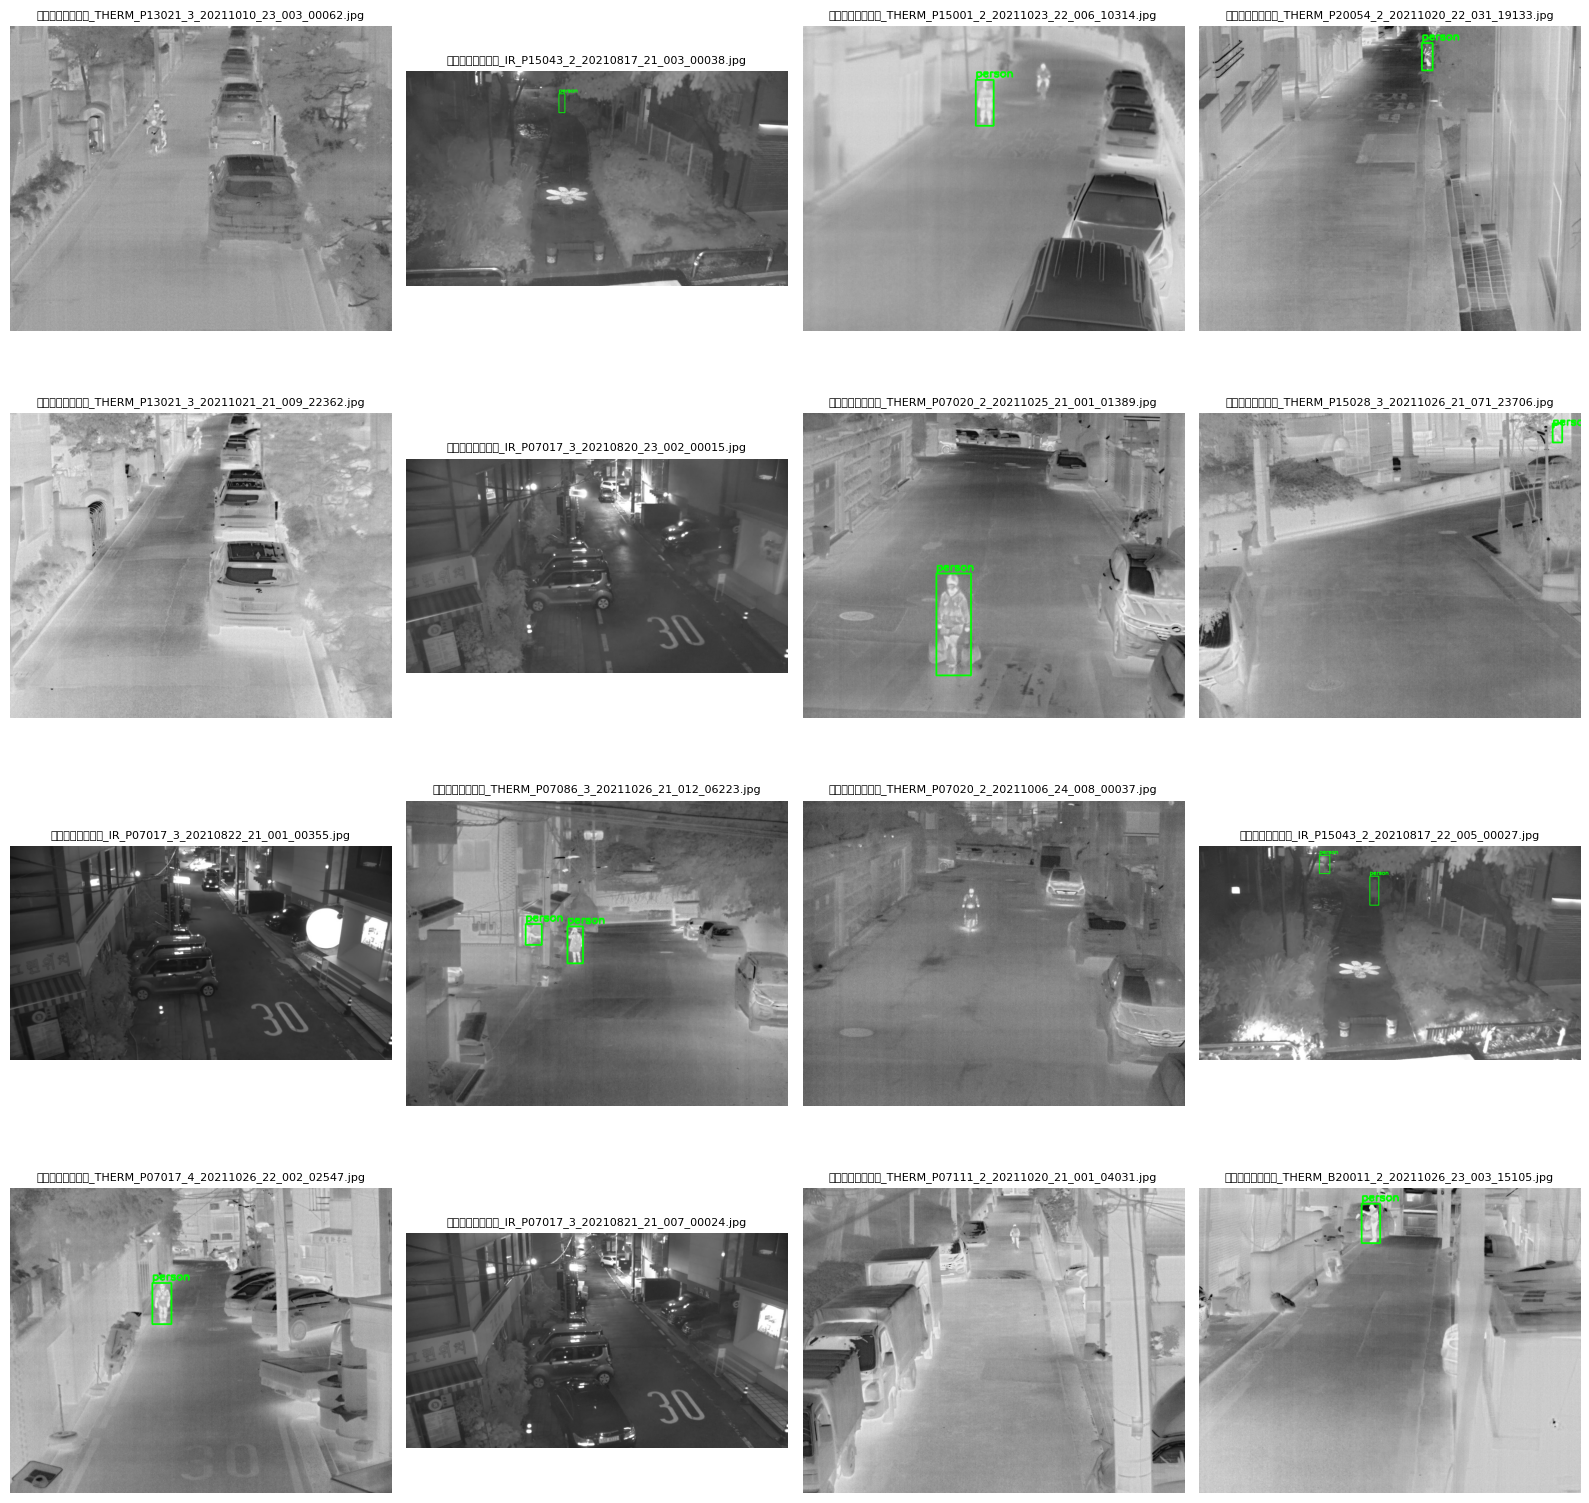

정상 출력 이미지 수: 16
읽기 실패 이미지 수: 0


In [ ]:
#===================================================================
# 데이터 품질 상태확인
#===================================================================

import os
import random
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

dataset_root = Path(r"C:\py_temp\person_target_data\dataset_v2")

img_dirs = [
    dataset_root / "images" / "train",
    dataset_root / "images" / "val"
]

label_dirs = {
    str(dataset_root / "images" / "train"): dataset_root / "labels" / "train",
    str(dataset_root / "images" / "val"): dataset_root / "labels" / "val"
}

image_files = []

for img_dir in img_dirs:
    for file in os.listdir(img_dir):
        if file.lower().endswith((".jpg", ".jpeg", ".png")):
            image_files.append(str(img_dir / file))

print("시각화 가능한 이미지 수:", len(image_files))

random.seed(10)
sample_files = random.sample(image_files, min(16, len(image_files)))

plt.figure(figsize=(16, 16))

valid_count = 0
skip_count = 0

for i, img_path_str in enumerate(sample_files, 1):
    img_path = Path(img_path_str)

    # 한글 경로 대응 방식
    file_bytes = np.fromfile(str(img_path), dtype=np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    if img is None:
        print("이미지 읽기 실패:", img_path)
        skip_count += 1
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    lbl_dir = label_dirs[str(img_path.parent)]
    lbl_path = lbl_dir / f"{img_path.stem}.txt"

    if lbl_path.exists():
        with open(lbl_path, "r", encoding="utf-8") as f:
            lines = f.readlines()

        for line in lines:
            line = line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) != 5:
                continue

            cls_id = int(parts[0])
            cx = float(parts[1])
            cy = float(parts[2])
            bw = float(parts[3])
            bh = float(parts[4])

            xmin = int((cx - bw / 2) * w)
            ymin = int((cy - bh / 2) * h)
            xmax = int((cx + bw / 2) * w)
            ymax = int((cy + bh / 2) * h)

            cv2.rectangle(img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
            cv2.putText(
                img,
                "person",
                (xmin, max(20, ymin - 5)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )

    valid_count += 1
    plt.subplot(4, 4, valid_count)
    plt.imshow(img)
    plt.title(img_path.name, fontsize=8)
    plt.axis("off")

    if valid_count == 16:
        break

plt.tight_layout()
plt.show()

print("정상 출력 이미지 수:", valid_count)
print("읽기 실패 이미지 수:", skip_count)

In [ ]:
import os
from pathlib import Path
from ultralytics import YOLO

# =========================================================
# 0. 경로 설정
# =========================================================
base_root = Path(r"C:\py_temp\person_target_data")
dataset_path = base_root / "dataset_v2"
project_path = base_root / "runs"

train_img_dir = dataset_path / "images" / "train"
val_img_dir   = dataset_path / "images" / "val"
train_lbl_dir = dataset_path / "labels" / "train"
val_lbl_dir   = dataset_path / "labels" / "val"

print("dataset exists:", dataset_path.exists())
print("train images:", len(os.listdir(train_img_dir)))
print("train labels:", len(os.listdir(train_lbl_dir)))
print("val images:", len(os.listdir(val_img_dir)))
print("val labels:", len(os.listdir(val_lbl_dir)))

# =========================================================
# 1. data.yaml 생성
# =========================================================
yaml_path = dataset_path / "person_dataset.yaml"

yaml_text = f"""
path: {dataset_path.as_posix()}
train: images/train
val: images/val

names:
  0: person
"""

with open(yaml_path, "w", encoding="utf-8") as f:
    f.write(yaml_text)

print("\ndata.yaml 생성 완료")
print(yaml_text)

# =========================================================
# 2. 모델 불러오기
# =========================================================
model = YOLO("yolo11n.pt")

# =========================================================
# 3. 1차 재학습
#    - 지금은 빠른 확인용이라 5 epoch
# =========================================================
model.train(
    data=str(yaml_path),
    epochs=5,
    imgsz=640,
    batch=4,
    project=str(project_path),
    name="person_v2_stage1",
    pretrained=True,
    mosaic=0.0,
    mixup=0.0,
    degrees=0.0,
    perspective=0.0,
    scale=0.3,
    fliplr=0.5,
    flipud=0.0,
    workers=2,
    verbose=True
)

# =========================================================
# 4. 학습 직후 검증 지표 출력
# =========================================================
metrics = model.val(data=str(yaml_path))

print("\n================ 1차 재학습 성능 =================")
try:
    print(f"Precision (정밀도)   : {metrics.box.mp:.4f}")
    print(f"Recall (재현율)      : {metrics.box.mr:.4f}")
    print(f"mAP50               : {metrics.box.map50:.4f}")
    print(f"mAP50-95            : {metrics.box.map:.4f}")
except:
    print("metrics 구조가 다를 수 있어 전체 출력:")
    print(metrics)
print("=================================================\n")

print("학습 결과 폴더:", project_path / "person_v2_stage1")
print("best.pt 경로  :", project_path / "person_v2_stage1" / "weights" / "best.pt")

dataset exists: True
train images: 127348
train labels: 127348
val images: 30227
val labels: 30227

data.yaml 생성 완료

path: C:/py_temp/person_target_data/dataset_v2
train: images/train
val: images/val

names:
  0: person

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.40  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1650 SUPER, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\py_temp\person_target_data\dataset_v2\person_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, free

In [ ]:
import os
from pathlib import Path
import cv2
import numpy as np
from ultralytics import YOLO

# =========================================================
# 0. 경로 설정
# =========================================================
base_root = Path(r"C:\py_temp\person_target_data")
dataset_path = base_root / "dataset_v2"
project_path = base_root / "runs"
run_name = "person_v2_stage1-2"

yaml_path = dataset_path / "person_dataset.yaml"
best_model_path = project_path / run_name / "weights" / "best.pt"

val_img_dir = dataset_path / "images" / "val"
val_lbl_dir = dataset_path / "labels" / "val"

failure_root = project_path / run_name / "failure_cases"
miss_dir = failure_root / "missed_person"
fp_dir = failure_root / "false_positive_on_empty"
mismatch_dir = failure_root / "mismatch"

miss_dir.mkdir(parents=True, exist_ok=True)
fp_dir.mkdir(parents=True, exist_ok=True)
mismatch_dir.mkdir(parents=True, exist_ok=True)

print("best model exists:", best_model_path.exists())
print("val image count:", len(os.listdir(val_img_dir)))

# =========================================================
# 1. 모델 로드
# =========================================================
model = YOLO(str(best_model_path))

# =========================================================
# 2. 전체 검증 성능 출력
# =========================================================
metrics = model.val(data=str(yaml_path))

print("\n================ 검증 성능 =================")
try:
    print(f"Precision (정밀도)   : {metrics.box.mp:.4f}")
    print(f"Recall (재현율)      : {metrics.box.mr:.4f}")
    print(f"mAP50               : {metrics.box.map50:.4f}")
    print(f"mAP50-95            : {metrics.box.map:.4f}")
except:
    print("metrics 구조가 다를 수 있어 전체 출력:")
    print(metrics)
print("==========================================\n")

# =========================================================
# 3. IoU 계산 함수
# =========================================================
def calc_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter = inter_w * inter_h

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

    union = area1 + area2 - inter + 1e-6
    return inter / union

# =========================================================
# 4. 검증 이미지별 실패 사례 찾기
# =========================================================
val_images = []
for file in os.listdir(val_img_dir):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        val_images.append(file)

miss_count = 0
fp_count = 0
mismatch_count = 0

save_limit_each = 50
saved_miss = 0
saved_fp = 0
saved_mismatch = 0

for idx, file in enumerate(val_images, 1):
    img_path = val_img_dir / file
    lbl_path = val_lbl_dir / f"{Path(file).stem}.txt"

    # 이미지 읽기 (한글 경로 대응)
    file_bytes = np.fromfile(str(img_path), dtype=np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    if img is None:
        continue

    h, w = img.shape[:2]

    # GT 박스 읽기
    gt_boxes = []
    if lbl_path.exists():
        with open(lbl_path, "r", encoding="utf-8") as f:
            lines = f.readlines()

        for line in lines:
            line = line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) != 5:
                continue

            cx = float(parts[1])
            cy = float(parts[2])
            bw = float(parts[3])
            bh = float(parts[4])

            xmin = int((cx - bw / 2) * w)
            ymin = int((cy - bh / 2) * h)
            xmax = int((cx + bw / 2) * w)
            ymax = int((cy + bh / 2) * h)

            gt_boxes.append([xmin, ymin, xmax, ymax])

    # 예측
    result = model.predict(
        source=str(img_path),
        conf=0.25,
        iou=0.5,
        save=False,
        verbose=False
    )[0]

    pred_boxes = []
    if result.boxes is not None and len(result.boxes) > 0:
        xyxy = result.boxes.xyxy.cpu().numpy()
        for box in xyxy:
            pred_boxes.append([int(box[0]), int(box[1]), int(box[2]), int(box[3])])

    gt_count = len(gt_boxes)
    pred_count = len(pred_boxes)

    save_img = img.copy()

    # GT는 초록
    for box in gt_boxes:
        cv2.rectangle(save_img, (box[0], box[1]), (box[2], box[3]), (0, 255, 0), 2)
    # Pred는 빨강
    for box in pred_boxes:
        cv2.rectangle(save_img, (box[0], box[1]), (box[2], box[3]), (0, 0, 255), 2)

    # 1) 사람 놓침
    if gt_count > 0 and pred_count == 0:
        miss_count += 1
        if saved_miss < save_limit_each:
            out_path = miss_dir / file
            cv2.imencode(".jpg", save_img)[1].tofile(str(out_path))
            saved_miss += 1
        continue

    # 2) 빈 장면 오탐
    if gt_count == 0 and pred_count > 0:
        fp_count += 1
        if saved_fp < save_limit_each:
            out_path = fp_dir / file
            cv2.imencode(".jpg", save_img)[1].tofile(str(out_path))
            saved_fp += 1
        continue

    # 3) 둘 다 있는데 위치가 잘 안 맞는 경우
    if gt_count > 0 and pred_count > 0:
        max_iou_list = []

        for gt in gt_boxes:
            best_iou = 0.0
            for pred in pred_boxes:
                iou = calc_iou(gt, pred)
                if iou > best_iou:
                    best_iou = iou
            max_iou_list.append(best_iou)

        # GT 중 하나라도 IoU<0.3이면 mismatch로 판단
        if len(max_iou_list) > 0 and min(max_iou_list) < 0.3:
            mismatch_count += 1
            if saved_mismatch < save_limit_each:
                out_path = mismatch_dir / file
                cv2.imencode(".jpg", save_img)[1].tofile(str(out_path))
                saved_mismatch += 1

    if idx % 1000 == 0:
        print(f"{idx}장 처리 완료")

# =========================================================
# 5. 실패 요약 출력
# =========================================================
print("\n================ 실패 분석 결과 ================")
print("총 검증 이미지 수           :", len(val_images))
print("사람 놓침 이미지 수        :", miss_count)
print("빈 장면 오탐 이미지 수     :", fp_count)
print("GT-Pred mismatch 이미지 수 :", mismatch_count)
print("------------------------------------------------")
print("miss 저장 수               :", saved_miss)
print("fp 저장 수                 :", saved_fp)
print("mismatch 저장 수           :", saved_mismatch)
print("================================================\n")

print("실패 사례 저장 폴더:")
print("missed_person         ->", miss_dir)
print("false_positive_empty  ->", fp_dir)
print("mismatch              ->", mismatch_dir)

best model exists: True
val image count: 30227
Ultralytics 8.4.40  Python-3.10.20 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce GTX 1650 SUPER, 4096MiB)
YOLO11n summary (fused): 101 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 98.317.6 MB/s, size: 109.4 KB)
val: Scanning C:\py_temp\person_target_data\dataset_v2\labels\val.cache... 30227 images, 14541 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 30227/30227  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1890/1890 7.2it/s 4:21<0.2s
                   all      30227      17742      0.919      0.841      0.904      0.648
Speed: 1.0ms preprocess, 5.0ms inference, 0.0ms loss, 0.6ms postprocess per image
Results saved to C:\py_temp\runs\detect\val-3

================ 검증 성능 =================
Precision (정밀도)   : 0.9186
Recall (재현율)      : 0.8411
mAP50               : 0.9040
mAP50-95            : 0.6484

1000장 처리 완료
2000장 처리 완료
300

In [ ]:
import os
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
from ultralytics import YOLO

# =========================================================
# 0. 경로 설정
# =========================================================
base_root = Path(r"C:\py_temp\person_target_data")
dataset_path = base_root / "dataset_v2"
project_path = base_root / "runs"

run_name = "person_v2_stage1-2"   # 네 실제 폴더명으로 수정
best_model_path = project_path / run_name / "weights" / "best.pt"

val_img_dir = dataset_path / "images" / "val"
val_lbl_dir = dataset_path / "labels" / "val"

print("best model exists:", best_model_path.exists())
print("val image count:", len(os.listdir(val_img_dir)))

# =========================================================
# 1. 모델 로드
# =========================================================
model = YOLO(str(best_model_path))

# =========================================================
# 2. IoU 함수
# =========================================================
def calc_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter = inter_w * inter_h

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

    union = area1 + area2 - inter + 1e-6
    return inter / union

# =========================================================
# 3. GT 로딩
#    - 반복 추론만 빠르게 하려고 GT를 먼저 메모리에 올림
# =========================================================
gt_data = {}

val_images = []
for file in os.listdir(val_img_dir):
    if file.lower().endswith((".jpg", ".jpeg", ".png")):
        val_images.append(file)

for file in val_images:
    img_path = val_img_dir / file
    lbl_path = val_lbl_dir / f"{Path(file).stem}.txt"

    file_bytes = np.fromfile(str(img_path), dtype=np.uint8)
    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
    if img is None:
        continue

    h, w = img.shape[:2]
    gt_boxes = []

    if lbl_path.exists():
        with open(lbl_path, "r", encoding="utf-8") as f:
            lines = f.readlines()

        for line in lines:
            line = line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) != 5:
                continue

            cx = float(parts[1])
            cy = float(parts[2])
            bw = float(parts[3])
            bh = float(parts[4])

            xmin = int((cx - bw / 2) * w)
            ymin = int((cy - bh / 2) * h)
            xmax = int((cx + bw / 2) * w)
            ymax = int((cy + bh / 2) * h)

            gt_boxes.append([xmin, ymin, xmax, ymax])

    gt_data[file] = {
        "img_path": str(img_path),
        "shape": (h, w),
        "gt_boxes": gt_boxes
    }

print("GT 로딩 완료:", len(gt_data))

# =========================================================
# 4. threshold 후보
#    - 처음엔 너무 많지 않게
# =========================================================
conf_list = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40]
iou_list  = [0.30, 0.40, 0.50, 0.60, 0.70]

results = []

# =========================================================
# 5. grid search
# =========================================================
for conf_th in conf_list:
    for iou_th in iou_list:
        TP = 0
        FP = 0
        FN = 0

        for idx, file in enumerate(val_images, 1):
            if file not in gt_data:
                continue

            img_path = gt_data[file]["img_path"]
            gt_boxes = gt_data[file]["gt_boxes"]

            pred_result = model.predict(
                source=img_path,
                conf=conf_th,
                iou=iou_th,
                save=False,
                verbose=False
            )[0]

            pred_boxes = []
            if pred_result.boxes is not None and len(pred_result.boxes) > 0:
                xyxy = pred_result.boxes.xyxy.cpu().numpy()
                for box in xyxy:
                    pred_boxes.append([int(box[0]), int(box[1]), int(box[2]), int(box[3])])

            matched_gt = set()
            matched_pred = set()

            # greedy matching
            for pi, pred_box in enumerate(pred_boxes):
                best_iou = 0.0
                best_gi = -1

                for gi, gt_box in enumerate(gt_boxes):
                    if gi in matched_gt:
                        continue
                    iou = calc_iou(pred_box, gt_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_gi = gi

                if best_iou >= 0.5 and best_gi != -1:
                    TP += 1
                    matched_gt.add(best_gi)
                    matched_pred.add(pi)

            FP += len(pred_boxes) - len(matched_pred)
            FN += len(gt_boxes) - len(matched_gt)

        precision = TP / (TP + FP + 1e-6)
        recall    = TP / (TP + FN + 1e-6)
        f1        = 2 * precision * recall / (precision + recall + 1e-6)

        # recall 우선 점수
        rank_score = (0.6 * recall) + (0.3 * f1) + (0.1 * precision)

        results.append({
            "conf": conf_th,
            "iou": iou_th,
            "TP": TP,
            "FP": FP,
            "FN": FN,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "rank_score": rank_score
        })

        print(f"[conf={conf_th:.2f}, iou={iou_th:.2f}] "
              f"P={precision:.4f}, R={recall:.4f}, F1={f1:.4f}, TP={TP}, FP={FP}, FN={FN}")

# =========================================================
# 6. 결과 정리
# =========================================================
df = pd.DataFrame(results)
df = df.sort_values(by=["rank_score", "recall", "f1"], ascending=False).reset_index(drop=True)

print("\n================ TOP 10 조합 ================\n")
print(df.head(10))

save_csv = project_path / run_name / "threshold_grid_search_results.csv"
df.to_csv(save_csv, index=False, encoding="utf-8-sig")

print("\n저장 완료:", save_csv)

best model exists: True
val image count: 30227
GT 로딩 완료: 30227
[conf=0.05, iou=0.30] P=0.8305, R=0.8771, F1=0.8532, TP=15562, FP=3176, FN=2180
[conf=0.05, iou=0.40] P=0.8287, R=0.8777, F1=0.8525, TP=15572, FP=3219, FN=2170
[conf=0.05, iou=0.50] P=0.8251, R=0.8792, F1=0.8513, TP=15599, FP=3307, FN=2143
[conf=0.05, iou=0.60] P=0.8148, R=0.8807, F1=0.8464, TP=15625, FP=3552, FN=2117
[conf=0.05, iou=0.70] P=0.7907, R=0.8820, F1=0.8338, TP=15648, FP=4142, FN=2094
[conf=0.10, iou=0.30] P=0.8915, R=0.8563, F1=0.8736, TP=15193, FP=1849, FN=2549
[conf=0.10, iou=0.40] P=0.8909, R=0.8568, F1=0.8735, TP=15201, FP=1861, FN=2541
[conf=0.10, iou=0.50] P=0.8889, R=0.8578, F1=0.8730, TP=15219, FP=1903, FN=2523
[conf=0.10, iou=0.60] P=0.8828, R=0.8592, F1=0.8709, TP=15244, FP=2023, FN=2498
[conf=0.10, iou=0.70] P=0.8684, R=0.8602, F1=0.8643, TP=15262, FP=2313, FN=2480
[conf=0.15, iou=0.30] P=0.9132, R=0.8429, F1=0.8766, TP=14954, FP=1422, FN=2788
[conf=0.15, iou=0.40] P=0.9128, R=0.8434, F1=0.8767, TP=1

In [5]:
import os
from pathlib import Path
import pandas as pd
from ultralytics import YOLO

# =========================================================
# 0. 경로 설정
# =========================================================
base_root = Path(r"C:\py_temp\person_target_data")
project_path = base_root / "runs"

run_name = "person_v2_stage1-2"   # 네 실제 학습 폴더명
best_model_path = project_path / run_name / "weights" / "best.pt"

test_dir = Path(r"C:\py_temp\person_target_data\real_test\1a")

save_root = project_path / run_name / "real_test_1a_results"
save_root.mkdir(parents=True, exist_ok=True)

print("best model exists:", best_model_path.exists())
print("test_dir exists:", test_dir.exists())

image_files = []
for file in os.listdir(test_dir):
    if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
        image_files.append(file)

print("테스트 이미지 수:", len(image_files))

# =========================================================
# 1. 모델 로드
# =========================================================
model = YOLO(str(best_model_path))

# =========================================================
# 2. 테스트 파라미터
#    - 현재 추천: 대표값/실전값 둘 다 가능
# =========================================================
conf_th = 0.10
iou_th = 0.50

# conf_th = 0.05   # 사람 놓침 최소화 쪽
# conf_th = 0.10   # 균형형 대표값

# =========================================================
# 3. 전체 폴더 예측 + 결과 저장
# =========================================================
results = model.predict(
    source=str(test_dir),
    conf=conf_th,
    iou=iou_th,
    save=True,
    project=str(save_root),
    name="pred_images",
    verbose=True
)

# =========================================================
# 4. 이미지별 결과 요약 정리
# =========================================================
rows = []

for result in results:
    file_path = Path(result.path)
    file_name = file_path.name

    det_count = 0
    max_conf = 0.0
    conf_list = []

    if result.boxes is not None and len(result.boxes) > 0:
        det_count = len(result.boxes)
        conf_arr = result.boxes.conf.cpu().numpy().tolist()
        conf_list = [round(float(x), 4) for x in conf_arr]
        max_conf = max(conf_arr)

    rows.append({
        "file_name": file_name,
        "det_count": det_count,
        "max_conf": round(float(max_conf), 4) if det_count > 0 else 0.0,
        "conf_list": str(conf_list)
    })

df = pd.DataFrame(rows)
df = df.sort_values(by=["det_count", "max_conf"], ascending=[False, False]).reset_index(drop=True)

csv_path = save_root / "pred_images" / "prediction_summary.csv"
df.to_csv(csv_path, index=False, encoding="utf-8-sig")

# =========================================================
# 5. 콘솔 요약 출력
# =========================================================
total_images = len(df)
detected_images = (df["det_count"] > 0).sum()
no_detect_images = (df["det_count"] == 0).sum()
multi_detect_images = (df["det_count"] >= 2).sum()

print("\n================ 테스트 요약 ================")
print("전체 이미지 수              :", total_images)
print("1명 이상 탐지된 이미지 수   :", detected_images)
print("0명 탐지된 이미지 수        :", no_detect_images)
print("2명 이상 탐지된 이미지 수   :", multi_detect_images)
print("탐지 비율                   :", round(detected_images / total_images, 4) if total_images > 0 else 0)
print("===========================================\n")

print("상위 20개 (탐지 많은 순)")
print(df.head(20))

print("\n0명 탐지 이미지 예시 20개")
print(df[df["det_count"] == 0].head(20))

print("\n결과 이미지 저장 폴더:")
print(save_root / "pred_images")

print("\n요약 CSV:")
print(csv_path)

best model exists: True
test_dir exists: True
테스트 이미지 수: 1054

WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1054 C:\py_temp\person_target_data\real_test\1a\img_00001.bmp: 480x640 2 persons, 86.2ms
image 2/1054 C:\py_temp\person_target_data\real_test\1a\img_00003.bmp: 480x640 2 persons, 9.1ms
image 3/1054 C:\py_temp\person_target_data\real_test\1a\img_00005.bmp: 480x640 2 persons, 9.5ms
image 4/1054 C:\py_temp\person_target_data\real_test\1a\img_00007.bmp: 480x640 2 persons, 8.5ms
image 5/1054 C

In [ ]:
import sys
!{sys.executable} -m pip install pandas opencv-python matplotlib pillow pyyaml

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 2.8 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/11.3 MB 2.7 MB/s eta 0:00:04
   ----- ---------------------------------- 1.6/11.3 MB 2.9 MB/s eta 0:00:04
   ------- -------------------------------- 2.1/11.3 MB 2.6 MB/s eta 0:00:04
   --------- ------------------------------ 2.6/11.3 MB 2.7 MB/s eta 0:00:04
   ----------- ---------------------------- 3.1/11.3 MB 2.6 MB/s eta 0:00:04
   ------------ --------------------------- 3.7/11.3 MB 2.6 MB/s eta 0:00:03
   -------------- ------------------------- 4.2/11.3 MB 2.6 MB/s eta 0:00:03
   ---------------- ----------------------- 4.7/11.3 MB 2.6 MB/s eta 0:00:03
   ------------------- -------------------- 5.5/11.3 MB 2.7 MB/s eta 0:00:03
   -------------------- ------------------- 5.8/11.3 MB 2.6 MB/s eta 0:00:03
   ---------------------- ----------------- 6.3/11.3 MB 2.5 MB/s eta 0:00:02
   ---

In [ ]:
import pandas as pd
import cv2
import yaml
import matplotlib

print("pandas:", pd.__version__)
print("cv2:", cv2.__version__)
print("yaml: ok")
print("matplotlib:", matplotlib.__version__)

pandas: 2.3.3
cv2: 4.13.0
yaml: ok
matplotlib: 3.10.8
